In [1]:
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'

input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)
numfiles=18000#3426
print("Loading a fixed set of ",numfiles," files")# Amount to ~1GB on disk without filtering or 312GB with prefiltering
input_filepaths=input_filepaths[:numfiles]
feature_description = {
    "input":  tf.io.FixedLenFeature([], tf.string),
    "output": tf.io.FixedLenFeature([], tf.string),
}


print(f'Number of input files: {len(input_filepaths)}')

# tf.py_function that creates a histogram of MIDI note occurrences from the label data in the TFRecord files
def createhist(labels):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    output_data = labels.numpy()  # Reshape to (num_frames, 89)
    for note in range(OUTPUT_DIM_NOTES):
        if output_data[note] == 1:
            hist[note] += 1
    return hist

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = tf.io.decode_raw(parsed["input"], tf.float32)
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    # hist = tf.py_function(createhist, [label], tf.int32)
    return audio,label

def create_dataset(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    dataset=dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def count_midi_notes(dataset):
    # hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    # 2. Define the reduction function
    # 'old_state' is the current sum, 'next_element' is (features, labels)
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # Cast labels to int32 to match state and prevent overflow
        return old_state + tf.cast(labels, tf.int32)

    # 3. Perform the reduction
    # This happens in the TF graph and is memory-efficient
    hist = dataset.reduce(initial_state, reduce_fn)
    
    return hist.numpy()

def plot_histogram(hist,size=OUTPUT_DIM_NOTES):
    plt.bar(range(size), hist)
    plt.xlabel('MIDI Note Number')
    plt.ylabel('Count')
    plt.title('Histogram of MIDI Note Occurrences')
    plt.xlim(0, size)  # Limit x-axis to the range of interest
    plt.show()
def filter_notes(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels

        for note in range(OUTPUT_DIM_NOTES):
            hist[note]+=labels[note]
            # if labels[note] == 1:
            #     if hist[note] >= note_count_maximum: 
            #         result=False
        # assert labels[OUTPUT_DIM_NOTES-1]==0
        
        # Check the minimum count for notes that are present in the current sample
        masks = labels == 1
        #print("Mask for current sample:", masks)
        min_count = np.min(hist[masks]) if np.any(masks) else 0
        # print("Current histogram:", hist)
        # print("Min count for current sample:", min_count)
        # if min_count>0:
        #     print("Minimum count for notes with occurrences:", min_count)
        if min_count >= note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

def filter_polyphony(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels
        num_active_notes=np.sum(labels[:(OUTPUT_DIM_NOTES-1)])
        if num_active_notes>=hist.shape[0]:  
            print("Warning: num_active_notes exceeds histogram size. This should not happen. num_active_notes:", num_active_notes, "histogram size:", hist.shape[0])
            return False        

        if hist[num_active_notes] > note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        else:
            hist[num_active_notes]+=1
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

def _bytes_feature(value: bytes) -> tf.train.Feature:
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))
def serialize_example(input: np.ndarray, output: np.ndarray) -> bytes:
    feature = {
        "input":  _bytes_feature(input.tobytes()),
        "output": _bytes_feature(output.tobytes()),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()
def write_tfrecord(dataset, output_filepath):
    with tf.io.TFRecordWriter(output_filepath) as writer:
        for audio, label in dataset:
            
            example = serialize_example(audio.numpy(), label.numpy())
            writer.write(example)

I0000 00:00:1770905955.395874  166842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1770905955.419171  166842 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1770905955.922694  166842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1770905956.286904  166842 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel bi

Filter mask created with shape: (312, 129)
Loading a fixed set of  18000  files
Number of input files: 18000


In [ ]:


dataset = create_dataset(input_filepaths)
print("Dataset created, counting MIDI notes...")
print("This may take a while...")

# midi_histogram = count_midi_notes(dataset)
# plot_histogram(midi_histogram)

note_count_maximum = 1000000#0.2*10**6
# Create dataset in which each note is limited to a maximum count of note_count_maximum by filtering out samples with that note until the count is below the maximum




# Write the audio and label data of the filtered dataset to new TFRecord files


#Create output directory if it doesn't exist
os.makedirs(subset, exist_ok=True)

output_filepath = os.path.join(subset, 'filtered_data.tfrecord')
midi_histogram= np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
filtered_dataset = dataset.filter(filter_notes(midi_histogram,note_count_maximum))
write_tfrecord(filtered_dataset, output_filepath)
print(f"Filtered dataset written to {output_filepath}")




# Create a new dataset with the filtered samples
midi_histogram= np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
filtered_dataset = dataset.filter(filter_notes(midi_histogram,note_count_maximum))
# print("Length of filtered dataset:", len(filtered_dataset))
print("Filtered dataset created, counting MIDI notes again...")
filtered_midi_histogram = count_midi_notes(filtered_dataset)
plot_histogram(filtered_midi_histogram)


Dataset created, counting MIDI notes...
This may take a while...
Filtered dataset created, counting MIDI notes again...


I0000 00:00:1770905956.908204  166997 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Histogram of concurrent notes in the filtered dataset: [3504102 2020075  478819  285511   71713   11680   10771     155      60
      33]


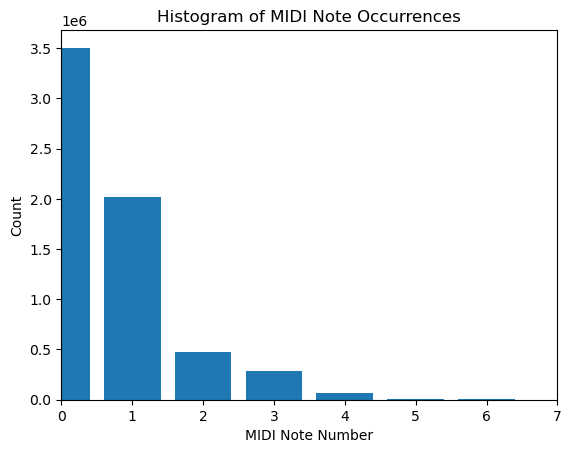

Minimum number of concurrent notes in the filtered dataset: 10771
Maximum number of concurrent notes in the filtered dataset: 3504102
Concurrent notes cap for training:  71713


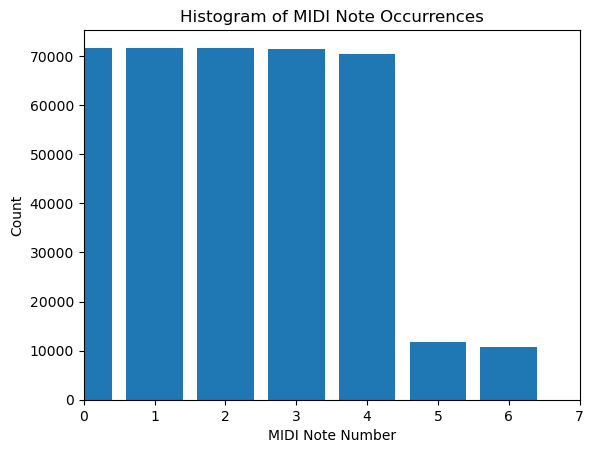

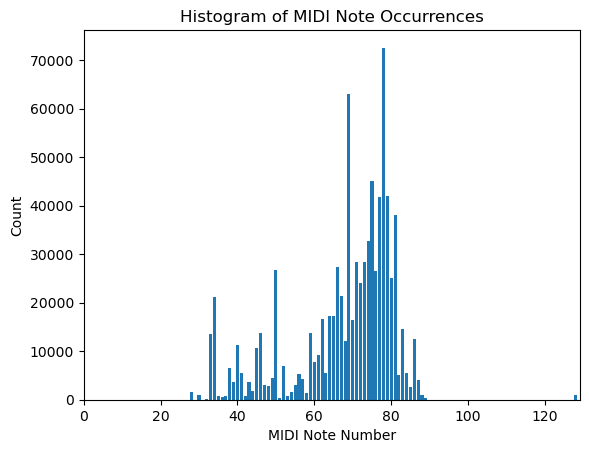

In [ ]:
# Load the filtered dataset and create a histogram over the number of concurrent notes in the labels
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_data.tfrecord'
filtered_dataset = create_dataset(subset)
def count_concurrent_notes_distribution(dataset, max_polyphony=10):
    # We want a histogram where index 0 = count of silent frames, 
    # index 1 = count of single-note frames, etc.
    initial_state = tf.zeros((max_polyphony,), dtype=tf.int64)
    
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # 1. Count how many 1s are in this specific label vector
        num_active = tf.cast(tf.reduce_sum(labels), tf.int32)
        
        # 2. Ensure we don't go out of bounds of our histogram
        num_active = tf.minimum(num_active, max_polyphony - 1)
        
        # 3. Create a one-hot vector to increment only the specific bin
        # e.g., if 3 notes are active, update_mask = [0, 0, 0, 1, 0...]
        update_mask = tf.one_hot(num_active, depth=max_polyphony, dtype=tf.int64)
        
        return old_state + update_mask

    hist = dataset.reduce(initial_state, reduce_fn)
    return hist.numpy()

# Now run it
# concurrent_notes_histogram = count_concurrent_notes_distribution(filtered_dataset)
print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
plot_histogram(concurrent_notes_histogram[:7],7)
   
#print the minimum and maximum number of concurrent notes in the filtered dataset
min_concurrent_notes = np.min(concurrent_notes_histogram[:7])
max_concurrent_notes = np.max(concurrent_notes_histogram)
print(f"Minimum number of concurrent notes in the filtered dataset: {min_concurrent_notes}")
print(f"Maximum number of concurrent notes in the filtered dataset: {max_concurrent_notes}")

concurrent_notes_cap=concurrent_notes_histogram[4]
print("Concurrent notes cap for training: ", concurrent_notes_cap)

polyphony_histogram= np.zeros((11,), dtype=int)
filtered_poly_dataset = filtered_dataset.filter(filter_polyphony(polyphony_histogram,concurrent_notes_cap))
concurrent_notes_histogram_poly = count_concurrent_notes_distribution(filtered_poly_dataset)
plot_histogram(concurrent_notes_histogram_poly[:7],7)

polyphony_histogram= np.zeros((11,), dtype=int)
filtered_poly_dataset = filtered_dataset.filter(filter_polyphony(polyphony_histogram,concurrent_notes_cap))
write_tfrecord(filtered_poly_dataset, '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_data_poly.tfrecord')


polyphony_histogram= np.zeros((11,), dtype=int)
filtered_poly_dataset = filtered_dataset.filter(filter_polyphony(polyphony_histogram,concurrent_notes_cap))
midi_histogram_poly = count_midi_notes(filtered_poly_dataset)
plot_histogram(midi_histogram_poly)

